EM Structure
</p>
<em>Di Condition for EM Greek and Trojan at Earth Moon and Earth Moon Sun situation</em>
</p>
<img src="Di_Condition_EarthGreekTrojan_EM_EMS.png" alt="dd" style="width: 600px;"/>
</p>
Condition

webstie for time conversion
https://heasarc.gsfc.nasa.gov/cgi-bin/Tools/xTime/xTime.pl?time_in_i=&time_in_c=&time_in_d=&time_in_j=&time_in_m=60473.27430556016&time_in_sf=&time_in_wf=&time_in_ii=&time_in_sl=&time_in_sni=&time_in_snu=&time_in_s=&time_in_h=&time_in_sz=&time_in_ss=&time_in_sn=&time_in_sxr=&timesys_in=u&timesys_out=u&apply_clock_offset=yes

In [1]:
# sim is simulation class from rebound
# filename is the rebound simulation environment setup file
# filename,MJD_model,SMA,ECC,MJD_model,MA_config in radians
# record minimum distance to Jupiter
def MEGNO_from_rebound(filename,MJD_model,SMA,ECC,INC,RAAN,AOP,MA,**kwargs):
    sim = rebound.Simulation(filename)
    # Name, a, e, i, long. node, arg. peric., mean anomaly
    # Test Particle
    sim.add(primary=sim.particles[0], a=SMA, e=ECC, inc=INC, Omega=RAAN, omega=AOP, M=MA)
    #   plotting orbit
    #    for orbit in sim.calculate_orbits(primary=sim.particles[0]):
    #        print(orbit)
    #        print("M =", orbit.M)
    
    # integration time parameters
    tspan = kwargs['tspan']
    Long_term_year = tspan # 1 year is 1 year on Earth
    year = 2.*np.pi # One year in units where G=1
    time_propagate = Long_term_year*year
    
    # integrator parameters
    sim.integrator = kwargs['simintegrator']
    sim.dt = kwargs['simdt'] # we're working in units where 1 year = 2*pi
    sim.ri_ias15.min_dt = kwargs['sim_ias15dt'] # ensure that close encounters do not stall the integration
    sim.ri_ias15.epsilon = kwargs['epsilon'] # control accuracy for ias15
    
    sim.move_to_com()        # We always move to the center of momentum frame before an integration
    ps = sim.particles       # ps is now an array of pointers and will change as the simulation runs
    
    #sim.status() # show status in Cartesian coordinate
    sim.init_megno(seed=0)
    sim.exit_max_distance = 20.
    
    try:
        sim.integrate(time_propagate, exact_finish_time=0) # integrate for time_propagate, integrating to the nearest
        #timestep for each output to keep the timestep constant and preserve WHFast's symplectic nature
        megno = sim.megno() 
        return megno
    except rebound.Escape:
        return 100. # At least one particle got ejected, returning large MEGNO.

In [25]:
!pip install rebound matplotlib julian numpy pandas joblib

In [ ]:
import rebound
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import datetime, julian
from math import degrees, radians
from SolarSystem.solar_constant import *
import multiprocessing
from joblib import Parallel, delayed
from pathlib import Path
import time,os, signal, json

In [3]:
folder = "Data/"
# date
date = "2026-08-12 17:37:54" # time from small body data base
date_info = datetime.datetime.strptime(date,"%Y-%m-%d %H:%M:%S")
date_info_day=date_info.strftime("%Y-%m-%d")
MJD_model = julian.to_jd(date_info,fmt='mjd')
print(MJD_model)

61264.73465277767


In [4]:
# rebound simulation
rebound.horizons.SSL_CONTEXT = 'unverified'
sim = rebound.Simulation()
sim.add('Geocenter',date = date)
sim.add('Luna',primary=sim.particles[0])
sim.add('Sun',primary=sim.particles[0])

Searching NASA Horizons for 'Geocenter'... 
Found: Earth (399) 
Searching NASA Horizons for 'Luna'... 
Found: Moon (301) (chosen from query 'Luna')
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 


In [ ]:
# save to binary setup file
simfile = f"CislunarSun_{MJD_model}.bin"
# sim.save_to_file(simfile)
sim = rebound.Simulation(simfile)
print(f'{sim.units}')
# start_time = time.time()

{'length': 'au', 'mass': 'msun', 'time': 'yr2pi'}


In [5]:
# condition from Horizons in AU, deg
a_tess, e_tess, i_tess = 1.671088887083566E-03,6.380932362872992E-01,2.735501851350083E+01
Om_tess, w_tess, M_tess = 2.295025011248003E+02,5.488495273462943E+01,1.800061571716802E+02
sim.add(primary=sim.particles[0],a=a_tess,e=e_tess,inc=radians(i_tess),Omega=radians(Om_tess),omega=radians(w_tess),M=radians(M_tess))
particle = sim.particles[-1]
particle_orbit = particle.orbit(primary=sim.particles[0])
print(particle_orbit,'\n',particle_orbit.M)

<rebound.Orbit instance, a=0.0016710888870835278 e=0.6380932362873065 inc=0.47743514000459886 Omega=-2.2776110209898377 omega=0.9579231350207671 f=3.141623488952066> 
 3.1417001165051164


---------------------------------
REBOUND version:     	4.4.10
REBOUND built on:    	Jul  1 2025 16:04:54
Number of particles: 	3
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7f91bc9c2ba0, m=3.0034896154502038e-06 x=0.7708460889703567 y=-0.6611276368973026 z=0.00013534604458527444 vx=0.6317971429837519 vy=0.7590675603607332 vz=-1.7436950087816167e-05>
<rebound.particle.Particle object at 0x7f91bc9c24e0, m=3.694303350091508e-08 x=0.7689766879377882 y=-0.659539942583575 z=0.00017362390426681329 vx=0.6075611421175181 vy=0.7325370195303212 vz=-0.003261706174214936>
<rebound.particle.Particle object at 0x7f91bc9c2ba0, m=0.9999999999950272 x=-0.0015484237131927446 y=-0.00525530027280406 z=0.00010102320202253046 vx=0.000363318451046771 vy=0.00012584634018814343 vz=-7.574280842230701e-06>
---------------------------------
The following fields have non-default valu

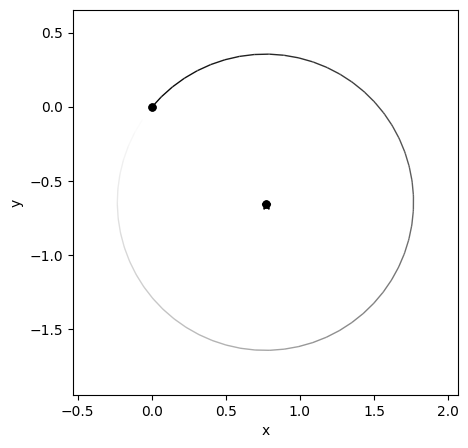

In [5]:
sim.status()
%matplotlib inline
fig = rebound.OrbitPlot(sim) #,slices=0.5,orbit_type="solid",xlim=[-1.,1.],ylim=[-1.1,-0.9])

In [7]:
vec_e2t = np.array(sim.particles[-1].xyz) - np.array(sim.particles[0].xyz)
vec_e2m = np.array(sim.particles[1].xyz) - np.array(sim.particles[0].xyz)
angle_t2m = degrees(np.arccos(np.dot(vec_e2t,vec_e2m)/(np.linalg.norm(vec_e2t)*np.linalg.norm(vec_e2m))))
print(angle_t2m)

54.22821364955063


In [8]:
# rebound propagation detail
simintegrator = 'ias15' #'mercurius'
simdt = 0.0001 # 2pi is 1 year, time follows equation t = simdt/(2*pi)*1*365.25 (day)
sim_ias15dt = 0 # ensure that close encounters do not stall the integration
epsilon = 1e-8 # control accuracy for ias15
tspan = 12 #10 #12 #8 #10 # 1 year is 1 year on Earth 365.25 solar days/earth days
No_output = 10000
rb_detail = {'simintegrator':simintegrator, 'simdt':simdt, 'sim_ias15dt':sim_ias15dt,
            'epsilon':epsilon, 'No_output':No_output, 'tspan':tspan}


In [9]:
moon_orbit = sim.particles[1].orbit(primary=sim.particles[0])  # Get Moon's orbital elements
i_eclip = moon_orbit.inc  # Moon's inclination in radians
print(f"Moon's inclination: {degrees(i_eclip):.2f} degrees")
sun_orbit = sim.particles[2].orbit(primary=sim.particles[0])  # Get Sun's orbital elements (particles[2] is Sun)
sun_inc = sun_orbit.inc  # Sun's inclination in radians
print(f"Sun's inclination: {degrees(sun_inc):.2f} degrees")

Moon's inclination: 5.07 degrees
Sun's inclination: 0.00 degrees


In [ ]:
# i_eclip = moon_orbit.inc # Use Moon's inclination for the test particle
i_eclip = 0.09208736524882595
INC_deg, RAAN_deg, AOP_deg, MA_deg = degrees(i_eclip), 0, 0, 180 # mean longitude = 180 deg = RAAN + AOP + MA
INC, RAAN, AOP, MA = radians(INC_deg), radians(RAAN_deg), radians(AOP_deg), radians(MA_deg)

SMA_min_Re, SMA_max_Re = 5, 240
SMA_min, SMA_max = SMA_min_Re*Re/AU, SMA_max_Re*Re/AU #AU
ECC_min, ECC_max = 0.01, 0.99
No_steps_SMA = 24#5#00 #250#0
No_steps_ECC = 4#8#0 #40#0
SMA_linspace = np.linspace(SMA_min,SMA_max,No_steps_SMA) 
ECC_linspace = np.linspace(ECC_min,ECC_max,No_steps_ECC) 
SMA_grid,ECC_grid = np.meshgrid(SMA_linspace,ECC_linspace)

# flatten for calculation
SMA_flatlist = SMA_grid.flatten().tolist()
ECC_flatlist = ECC_grid.flatten().tolist()
print(len(SMA_flatlist))

# Count number of cores
numCores = multiprocessing.cpu_count()

start_time = time.time()
megno_flatlist = Parallel(n_jobs = numCores)(delayed(MEGNO_from_rebound)(simfile,MJD_model,SMA,ECC,INC,RAAN,AOP,MA,**rb_detail) for SMA,ECC in zip(SMA_flatlist,ECC_flatlist))
print(time.time()-start_time)

96
31.664294958114624


In [ ]:
df = pd.DataFrame(list(zip(SMA_flatlist,ECC_flatlist,megno_flatlist)),columns =['SMA', 'ECC', 'MEGNO'])
df.to_csv(f'Data/MEGNO_{date}_span{tspan}_SMA{SMA_min_Re}_{SMA_max_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv')
# TP's universal ICs
df_IC = pd.DataFrame(list([date_info_day,INC,RAAN,AOP,MA]),index=['date','INC','RAAN','AOP','M'])
df_IC.to_csv(f'Data/IC_{date_info_day}_span{tspan}_SMA{SMA_min_Re}_{SMA_min_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv')

In [17]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=[20,10])
x = [i*AU/Re for i in SMA_flatlist]
y = ECC_flatlist
color = [np.log(i) for i in megno_flatlist]
plt.scatter(x, y, c=color, alpha=0.8, s=80)
plt.title('megno')
plt.xlabel('a (Re)')
plt.ylabel('e')
plt.colorbar()
plt.scatter(particle_orbit.a*AU/Re,particle_orbit.e,c='r',alpha=0.8,s=200)
fig.savefig("graph.pdf", bbox_inches='tight')
plt.show()

NameError: name 'SMA_flatlist' is not defined

<Figure size 2000x1000 with 0 Axes>

## Chunk running version

In [16]:
# i_eclip = moon_orbit.inc # Use Moon's inclination for the test particle
i_eclip = 0.09208736524882595
INC_deg, RAAN_deg, AOP_deg, MA_deg = degrees(i_eclip), 0, 0, 180 # mean longitude = 180 deg = RAAN + AOP + MA
INC, RAAN, AOP, MA = radians(INC_deg), radians(RAAN_deg), radians(AOP_deg), radians(MA_deg)
INC = degrees(i_eclip)

SMA_min_Re, SMA_max_Re = 5, 240
SMA_min, SMA_max = SMA_min_Re*Re/AU, SMA_max_Re*Re/AU #AU
ECC_min, ECC_max = 0.01, 0.99
No_steps_SMA = 24#5#00 #250#0
No_steps_ECC = 8#0 #40#0
# ==== your existing grid ====
SMA_linspace = np.linspace(SMA_min, SMA_max, No_steps_SMA)
ECC_linspace = np.linspace(ECC_min, ECC_max, No_steps_ECC)
SMA_grid, ECC_grid = np.meshgrid(SMA_linspace, ECC_linspace)

# make a stable index for each (SMA,ECC) pair
pairs = [(idx, float(SMA), float(ECC))
         for idx, (SMA, ECC) in enumerate(zip(SMA_grid.ravel(), ECC_grid.ravel()))]
total = len(pairs)

# ==== output paths ====
outdir = Path("Data")
outdir.mkdir(exist_ok=True)
outfile = outdir / f"MEGNO_{date}_span{tspan}_SMA{SMA_min_Re}_{SMA_max_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv"
done_json = outdir / f"MEGNO_{date}_span{tspan}_done_indices.json"

# write IC file once (if you like keeping it separate)
icfile = outdir / f"IC_{date_info_day}_span{tspan}_SMA{SMA_min_Re}_{SMA_max_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv"
if not icfile.exists():
    df_IC = pd.DataFrame(
        {"value":[date_info_day, INC, RAAN, AOP, MA]},
        index=["date","INC","RAAN","AOP","M"]
    )
    df_IC.to_csv(icfile)

# ==== load 'done' set if resuming ====
done = set()
if outfile.exists():
    try:
        # prefer indexing by 'idx' column if present
        existing = pd.read_csv(outfile, usecols=["idx"])
        done.update(existing["idx"].astype(int).tolist())
    except Exception:
        # fallback: infer by SMA/ECC (rounded to avoid fp noise)
        existing = pd.read_csv(outfile, usecols=["SMA","ECC"])
        seen = set(zip(np.round(existing["SMA"],12), np.round(existing["ECC"],12)))
        for i,(idx,SMA,ECC) in enumerate(pairs):
            if (round(SMA,12), round(ECC,12)) in seen:
                done.add(idx)

# also merge persisted done_json if present
if done_json.exists():
    try:
        done |= set(json.loads(done_json.read_text()))
    except Exception:
        pass

pending = [(i,s,e) for (i,s,e) in pairs if i not in done]
print(f"Total {total} | Done {len(done)} | Pending {len(pending)}")

# ==== graceful termination handling ====
terminate = {"flag": False}
def _sigterm(signum, frame): terminate["flag"] = True
signal.signal(getattr(signal, "SIGTERM", 15), _sigterm)

# ==== compute wrapper ====
def compute_one(idx, SMA, ECC):
    try:
        val = MEGNO_from_rebound(simfile, MJD_model, SMA, ECC, INC, RAAN, AOP, MA, **rb_detail)
        return {"idx": idx, "SMA": SMA, "ECC": ECC, "MEGNO": float(val),
                "INC": INC, "RAAN": RAAN, "AOP": AOP, "MA": MA}
    except Exception as ex:
        # keep the row with NaN + error for easy re-run filtering
        return {"idx": idx, "SMA": SMA, "ECC": ECC, "MEGNO": np.nan,
                "INC": INC, "RAAN": RAAN, "AOP": AOP, "MA": MA, "error": str(ex)}

# ==== execution params ====
numCores = max(1, multiprocessing.cpu_count() - 1)
batch_size = 48  # tune to your runtime per point

# write header if file new
write_header = not outfile.exists()

# ==== main loop ====
t0 = time.time()
for b0 in range(0, len(pending), batch_size):
    batch = pending[b0:b0+batch_size]
    results = Parallel(n_jobs=numCores, prefer="processes", batch_size="auto")(
        delayed(compute_one)(i, s, e) for (i, s, e) in batch
    )

    df = pd.DataFrame(results, columns=["idx","SMA","ECC","MEGNO","INC","RAAN","AOP","MA","error"])
    # append incrementally
    df.to_csv(outfile, mode="a", header=write_header, index=False)
    write_header = False

    # persist 'done' (only successes count as done; or keep all to avoid rework—choose one)
    for r in results:
        if np.isfinite(r.get("MEGNO", np.nan)):
            done.add(r["idx"])
    done_json.write_text(json.dumps(sorted(done)))

    print(f"Checkpointed {len(done)}/{total} in {time.time()-t0:.1f}s")

    if terminate["flag"]:
        print("Received SIGTERM: exiting cleanly after checkpoint.")
        break

print("Run finished (or cleanly stopped).")

Total 192 | Done 0 | Pending 192


Checkpointed 48/192 in 10.9s
Checkpointed 96/192 in 18.5s
Checkpointed 144/192 in 29.5s
Checkpointed 192/192 in 55.0s
Run finished (or cleanly stopped).


In [4]:
outfile = 'Data/MEGNO_2024-06-12 06:35:00_span12_SMA5_240_2500steps_ECC0.01_0.99_400steps.csv'

/home2/wud2/.conda/envs/REBOUND/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


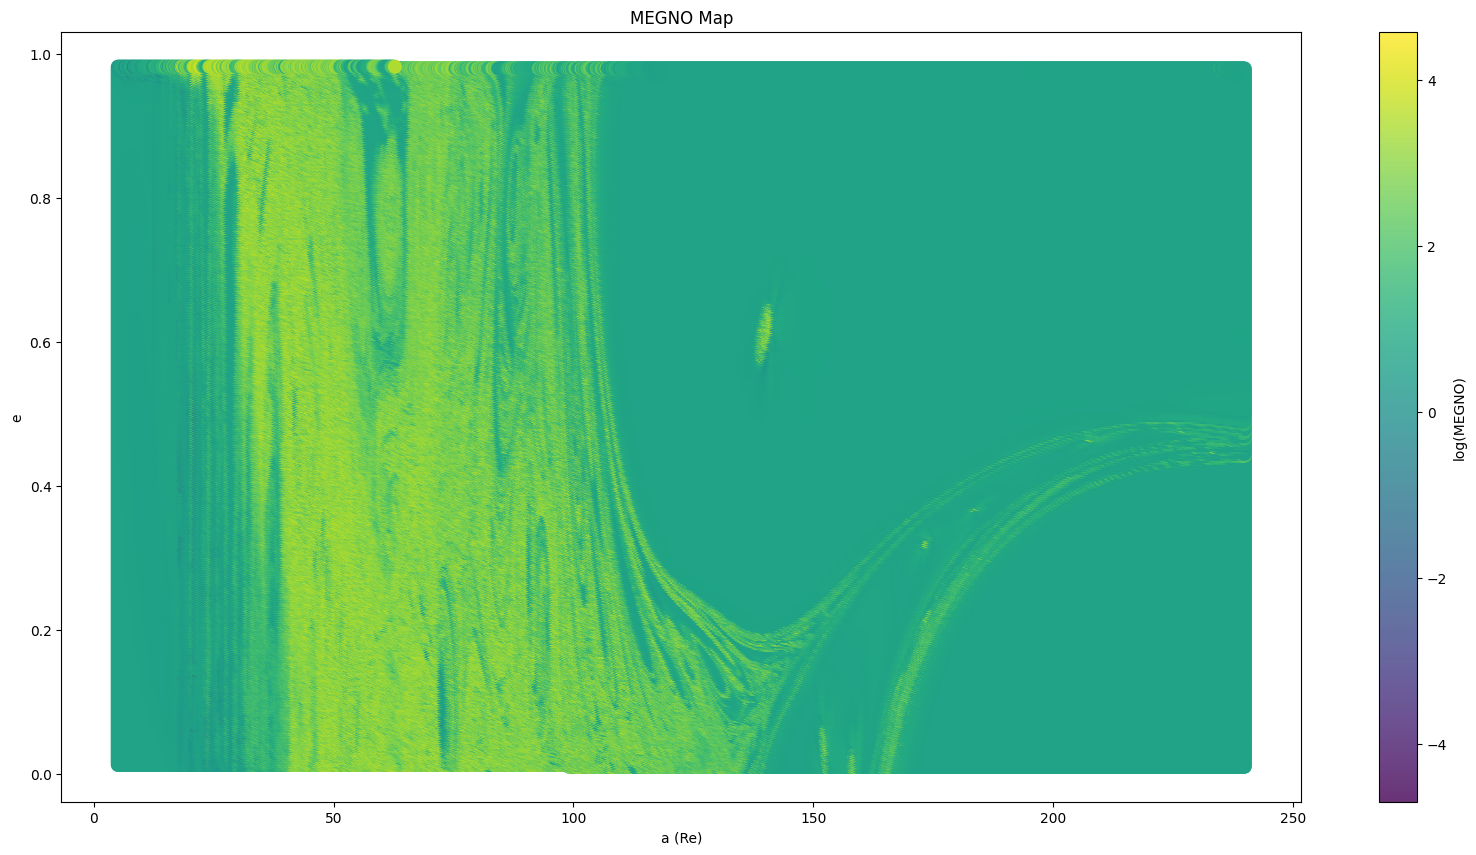

In [ ]:
# load the accumulated results
df = pd.read_csv(outfile)   # same 'outfile' you used to save batches

# convert SMA back into Earth radii (Re)
x = df["SMA"] * AU / Re
y = df["ECC"]

# log color scale of MEGNO values
color = np.log(df["MEGNO"])

fig, ax = plt.subplots(figsize=(20,10))
sc = ax.scatter(x, y, c=color, alpha=0.8, s=80, cmap="viridis")

ax.set_title("MEGNO Map")
ax.set_xlabel("a (Re)")
ax.set_ylabel("e")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("log(MEGNO)")

# overlay your reference particle orbit if any

# fig.savefig("graph.pdf", bbox_inches="tight")
plt.show()

## Testing MEGNO Calculation

In [6]:
binfile = "CislunarSun_61264.73465277767.bin"  # example file
SMA_au, ECC, MEGNO_pre, = 4.67153289e-03, 5.57719298e-01, 3.64171627e+01,
INC_deg, Omega_deg, omega_deg, MA_deg = 5.27621738e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00
INC, RAAN, AOP, MA = np.radians(INC_deg), np.radians(Omega_deg), np.radians(omega_deg), np.radians(MA_deg)

date = "2026-08-12 17:37:54" # time from small body data base
date_info = datetime.datetime.strptime(date,"%Y-%m-%d %H:%M:%S")
date_info_day=date_info.strftime("%Y-%m-%d")
MJD_model = julian.to_jd(date_info,fmt='mjd')

# rebound propagation detail
simintegrator = 'ias15' #'mercurius'
simdt = 0.0001 # 2pi is 1 year, time follows equation t = simdt/(2*pi)*1*365.25 (day)
sim_ias15dt = 0 # ensure that close encounters do not stall the integration
epsilon = 1e-8 # control accuracy for ias15
tspan = 12 #10 #12 #8 #10 # 1 year is 1 year on Earth 365.25 solar days/earth days
No_output = 10000
rb_detail = {'simintegrator':simintegrator, 'simdt':simdt, 'sim_ias15dt':sim_ias15dt,
            'epsilon':epsilon, 'No_output':No_output, 'tspan':tspan}

megno_out = MEGNO_from_rebound(binfile,MJD_model,SMA_au,ECC,INC,RAAN,AOP,MA,**rb_detail)
megno_out



1.6307575826217333